In [28]:
import pyarrow as pa
from PIL import Image
from io import BytesIO
from renaissance.datasets.coco_caption_karpathy_dataset import CocoCaptionKarpathyDataset
from transformers import ElectraConfig

from transformers import ElectraTokenizer, ViTImageProcessor
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import MinMaxScaler

In [29]:
generator = np.random.default_rng()
random_array = generator.random((10,519))
labels = np.concatenate([np.ones((3,)), np.zeros((7,))])
labels = labels[...,None]
complete_dataset = np.concatenate([random_array, labels], axis=1)
generator.shuffle(complete_dataset)

In [30]:
random_features = complete_dataset[:, :-1]
random_labels = complete_dataset[:,-1]

In [31]:
scaler = MinMaxScaler()
random_array = scaler.fit_transform(random_array)

In [32]:
classifier = SGDClassifier()
classifier.fit(random_array, random_labels)

SGDClassifier()

In [4]:
print(random_array[:,:-1].shape)
print(random_array[:, -1].shape)

(10, 519)
(10,)


In [2]:
tokenizer = ElectraTokenizer.from_pretrained("google/electra-base-discriminator")
image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

In [7]:
example_text = "This is a test sentence"
print(tokenizer.tokenize(example_text))
print(tokenizer(example_text))

['this', 'is', 'a', 'test', 'sentence']
{'input_ids': [101, 2023, 2003, 1037, 3231, 6251, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [17]:
electra_config = ElectraConfig()
print(electra_config.attribute_map)

{}


In [9]:
tokenizer.special_tokens_map

{'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]'}

In [3]:
coco_karpathy_dataset = CocoCaptionKarpathyDataset(split="val", 
                                                   transform_keys=["vit"], 
                                                   tokenizer=tokenizer, 
                                                   processor=image_processor,
                                                   data_dir="data/arrow/coco/",
                                                   include_wac_data=True)

In [13]:
returned_item = coco_karpathy_dataset.__getitem__(10)

print(returned_item['img_index'])
print(returned_item['cap_index'])

3
0


In [24]:
example_row = train_table.take([3])

In [25]:
example_table = pa.ipc.RecordBatchFileReader(pa.memory_map("data/arrow/coco/refcoco_unc_val.arrow", "r")).read_all()

In [40]:
max_bb = -1
for i in range(0, example_table.num_rows):
    bounding_boxes = len(example_table["bboxes"][i])
    if bounding_boxes > max_bb:
        max_bb = bounding_boxes

In [57]:
len(example_row["sentences"][0])

3

In [56]:
len(example_row["bboxes"][0])

14

In [17]:
example_image = Image.open(BytesIO(example_row["image"].to_pylist()[0]))

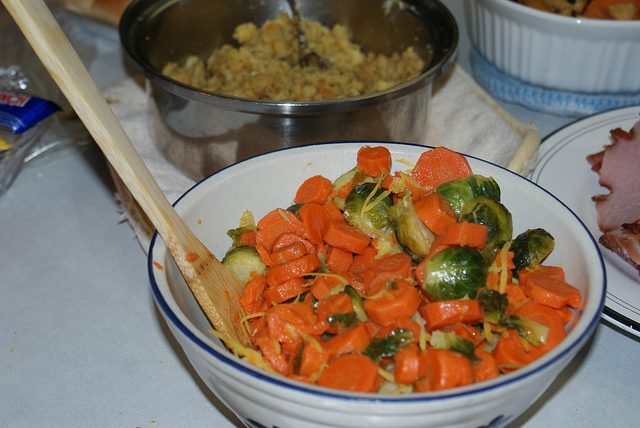

In [18]:
example_image